<a href="https://colab.research.google.com/github/chewanna7-code/NatureInsightStudy/blob/main/Individual_AHP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================================================
# Analytic Hierarchy Process (AHP) Weighting Tool
# =========================================================
# This script allows users to:
# 1. Select either preset or custom AHP weighting
# 2. Perform pairwise comparisons between relevant criteria
# 3. Generate weighted importance scores, which can be applied to decision making between trade-offs
# 4. Evaluate consistency using the Saaty Consistency Ratio, to validate the inputs
#
# Developed for:
# Nature-based flood management trade-off study (a trade-off matrix more specifically)
# within the River Wansbeck NatureInsight® study
# =========================================================

# Select weighting method
Option 1:Use predefined literature/stakeholder weightings

Option 2: Create a custom AHP matrix manually

In [ ]:
mode = input("Select weighting method: (1) Literature-based preset or (2) Create your own AHP: ").strip()
if mode == "1":
    print("Preset mode selected")
elif mode == "2":
    print("Custom AHP mode selected")
else:
    print("Invalid selection")

Select weighting method: (1) Literature-based preset or (2) Create your own AHP: 1
Preset mode selected


These criteria were selected for the purpose of my study, but can act interchangably for any AHP assessment. They were selcted through literature studies, assessing case studies and frameworks, and common themes amongst them

In [ ]:
import numpy as np

# ---------------------------
# 1. Define criteria
# ---------------------------
criteria = [
    "Storage",
    "Habitat",
    "Carbon",
    "Cost",
    "Cost-Effectiveness",
    "Time to Effectiveness",
    "Durability",
    "Stakeholder Risk",
    "Policy Alignment",
    "Disservices Risk"
]
# Number of criteria
n = len(criteria)

# ---------------------------
# 2. Initialise pairwise matrix
# ---------------------------
matrix = np.ones((n, n))
skipped = [] # Store skipped comparisons for later review

# ---------------------------
# 3. Input conversion function
# ---------------------------
def convert_input(value):
    if value == "c":
        return 1
    try:
        val = int(value)
        # First criterion more important
        if val > 0:
            return val
        # Second criterion more important
        elif val < 0:
            return 1 / abs(val)
    except:
        return None

# ---------------------------
# 4. Instructions for AHP creation
# ---------------------------
print("\n--- AHP Pairwise Comparison ---")
print("Use the following scale:")
print("c = equal importance")
print("1,3,5,7,9 = first is more important")
print("-1,-3,-5,-7,-9 = second is more important")
print("a = unsure (will revisit later)\n")

# ---------------------------
# 5. Pairwise comparisons
# Users compare every criterion against every other.
#
# Only upper triangle is completed manually.
# Reciprocal values are automatically computed, to increase efficiency and reduce repeating.
# ---------------------------
for i in range(n):
    for j in range(i + 1, n):
        while True:
            print(f"\nCompare: {criteria[i]} vs {criteria[j]}")
            user_input = input("Enter value: ").strip().lower()

            if user_input in ["a", "b"]:
                skipped.append((i, j))
                break

            value = convert_input(user_input)

            if value is not None:
                matrix[i][j] = value
                matrix[j][i] = 1 / value
                break
            else:
                print("Invalid input, try again.")

# ---------------------------
# 6. Revisit skipped, if any were skipped previosuly
# ---------------------------
if skipped:
    print("\n--- Revisiting skipped comparisons ---")
    for (i, j) in skipped:
        while True:
            print(f"\nCompare: {criteria[i]} vs {criteria[j]}")
            user_input = input("Enter value: ").strip().lower()

            value = convert_input(user_input)

            if value is not None:
                matrix[i][j] = value
                matrix[j][i] = 1 / value
                break
            else:
                print("Invalid input, try again.")

# ---------------------------
# 7. Calculate weights of AHP
# sum matrix, then normalise the matrix values and average the rows to find weights generated

# ---------------------------
col_sum = np.sum(matrix, axis=0)
norm_matrix = matrix / col_sum
weights = np.mean(norm_matrix, axis=1)

# ---------------------------
# 8. Output results
# ---------------------------
print("\n--- Final Weights ---")
for i in range(n):
    print(f"{criteria[i]}: {weights[i]:.3f}")

print(f"\nTotal weight sum: {np.sum(weights):.3f}")


--- AHP Pairwise Comparison ---
Use the following scale:
c = equal importance
1,3,5,7,9 = first is more important
-1,-3,-5,-7,-9 = second is more important
a = unsure (will revisit later)


Compare: Storage vs Habitat
Enter value: 2

Compare: Storage vs Carbon
Enter value: 2

Compare: Storage vs Cost
Enter value: 2

Compare: Storage vs Cost-Effectiveness
Enter value: 
Invalid input, try again.

Compare: Storage vs Cost-Effectiveness
Enter value: 2

Compare: Storage vs Time to Effectiveness
Enter value: 2

Compare: Storage vs Durability
Enter value: 2

Compare: Storage vs Stakeholder Risk
Enter value: 2

Compare: Storage vs Policy Alignment
Enter value: 2

Compare: Storage vs Disservices Risk
Enter value: 2

Compare: Habitat vs Carbon
Enter value: 2

Compare: Habitat vs Cost
Enter value: 2

Compare: Habitat vs Cost-Effectiveness
Enter value: 2

Compare: Habitat vs Time to Effectiveness
Enter value: 2

Compare: Habitat vs Durability
Enter value: 2

Compare: Habitat vs Stakeholder Risk
E

Can save the weighting to your device for future reuse.

In [ ]:
import pandas as pd

# ---------------------------
# Save results (weights + matrix)
# ---------------------------
save_choice = input("\nWould you like to save this weighting? (y/n): ").strip().lower()

if save_choice == "y":
    name = input("Enter a name for this weighting scenario: ").strip()
    safe_name = name.replace(" ", "_")

    # Create DataFrames
    df_weights = pd.DataFrame({
        "Criterion": criteria,
        "Weight": weights
    })

    df_matrix = pd.DataFrame(matrix, index=criteria, columns=criteria)

    # Define filenames
    weights_file = f"{safe_name}_weights.csv"
    matrix_file = f"{safe_name}_pairwise_matrix.csv"

    # Save files
    df_weights.to_csv(weights_file, index=False)
    df_matrix.to_csv(matrix_file)

    print(f"\nSaved:")
    print(f"- Weights → {weights_file}")
    print(f"- Pairwise matrix → {matrix_file}")


Would you like to save this weighting? (y/n): n


In [ ]:
import pandas as pd

# Convert matrix to DataFrame
df_matrix = pd.DataFrame(matrix, index=criteria, columns=criteria)

print("\n--- Pairwise Comparison Matrix ---")
print(df_matrix.round(3))


--- Pairwise Comparison Matrix ---
                       Storage  Habitat  Carbon  Cost  Cost-Effectiveness  \
Storage                    1.0      2.0     2.0   2.0                 2.0   
Habitat                    0.5      1.0     2.0   2.0                 2.0   
Carbon                     0.5      0.5     1.0   2.0                 2.0   
Cost                       0.5      0.5     0.5   1.0                 2.0   
Cost-Effectiveness         0.5      0.5     0.5   0.5                 1.0   
Time to Effectiveness      0.5      0.5     0.5   0.5                 0.5   
Durability                 0.5      0.5     0.5   0.5                 0.5   
Stakeholder Risk           0.5      0.5     0.5   0.5                 0.5   
Policy Alignment           0.5      0.5     0.5   0.5                 0.5   
Disservices Risk           0.5      0.5     0.5   0.5                 0.5   

                       Time to Effectiveness  Durability  Stakeholder Risk  \
Storage                               

Heatmap of Pairwise comparison, to look at the outcome of relationships

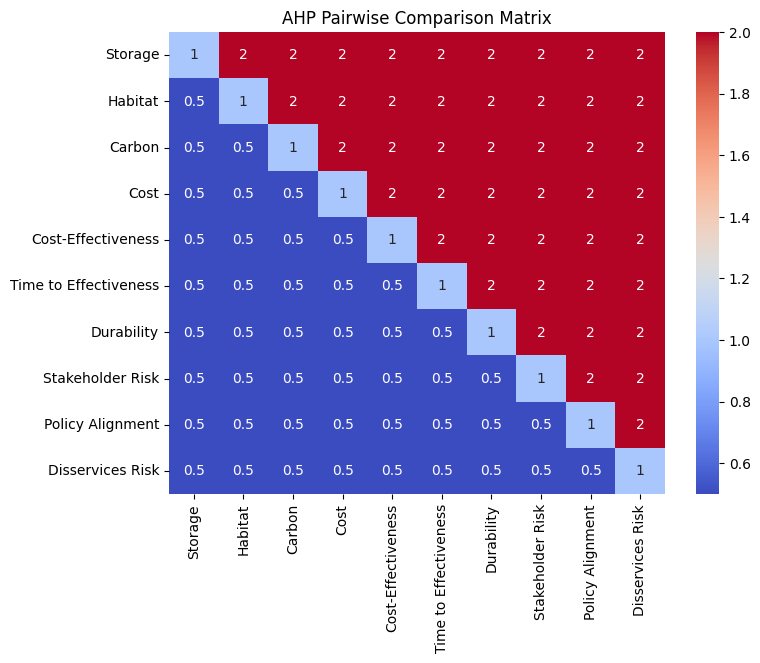

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df_matrix = pd.DataFrame(matrix, index=criteria, columns=criteria)

plt.figure(figsize=(8,6))
sns.heatmap(df_matrix, annot=True, cmap="coolwarm")
plt.title("AHP Pairwise Comparison Matrix")
plt.show()

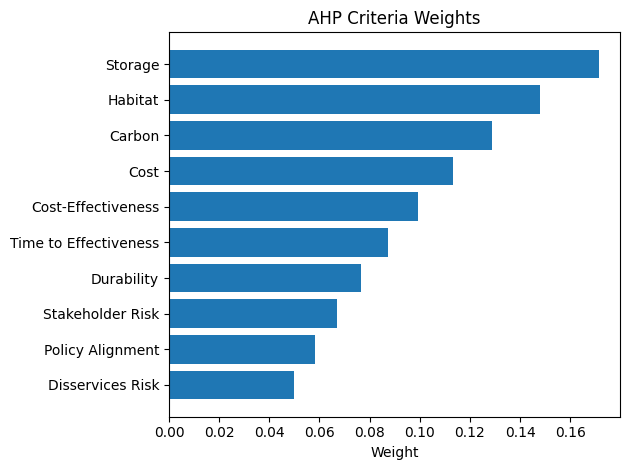

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Sort weights (so highest appears at top)
sorted_indices = np.argsort(weights)
sorted_criteria = [criteria[i] for i in sorted_indices]
sorted_weights = weights[sorted_indices]

plt.figure()

plt.barh(sorted_criteria, sorted_weights)

plt.xlabel("Weight")
plt.title("AHP Criteria Weights")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# =========================================================
# 8. Saaty Consistency Check
# =========================================================
# The Consistency Ratio (CR) assesses whether
# pairwise comparisons are logically consistent.
#
# CR < 0.10 is generally considered acceptable.
# =========================================================

# Random Index (RI) values from Saaty
RI_dict = {
    1: 0.00,
    2: 0.00,
    3: 0.58,
    4: 0.90,
    5: 1.12,
    6: 1.24,
    7: 1.32,
    8: 1.41,
    9: 1.45,
    10: 1.49
}

# Weighted sum vector
weighted_sum = np.dot(matrix, weights)

# Consistency vector
consistency_vector = weighted_sum / weights

# Principal eigenvalue approximation
lambda_max = np.mean(consistency_vector)

# Consistency Index (CI)
CI = (lambda_max - n) / (n - 1)

# Random Index (RI)
RI = RI_dict[n]

# Consistency Ratio (CR)
CR = CI / RI

# =========================================================
# 9. Output final results
# =========================================================

print("\n=================================================")
print("Final AHP Weights")
print("=================================================")

for i in range(n):
    print(f"{criteria[i]}: {weights[i]:.3f}")

print("\n---------------------------------")
print(f"Total weight sum: {np.sum(weights):.3f}")
print("---------------------------------")

# =========================================================
# 10. Output consistency results
# =========================================================

print("\n=================================================")
print("Saaty Consistency Check")
print("=================================================")

print(f"Lambda Max: {lambda_max:.3f}")
print(f"Consistency Index (CI): {CI:.3f}")
print(f"Consistency Ratio (CR): {CR:.3f}")

# Interpret consistency
if CR < 0.10:
    print("\nConsistency is ACCEPTABLE")
else:
    print("\nConsistency is POOR")
    print("Consider revisiting pairwise comparisons.")


Final AHP Weights
Storage: 0.171
Habitat: 0.148
Carbon: 0.129
Cost: 0.113
Cost-Effectiveness: 0.099
Time to Effectiveness: 0.087
Durability: 0.077
Stakeholder Risk: 0.067
Policy Alignment: 0.058
Disservices Risk: 0.050

---------------------------------
Total weight sum: 1.000
---------------------------------

Saaty Consistency Check
Lambda Max: 10.590
Consistency Index (CI): 0.066
Consistency Ratio (CR): 0.044

Consistency is ACCEPTABLE
